In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(1)

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

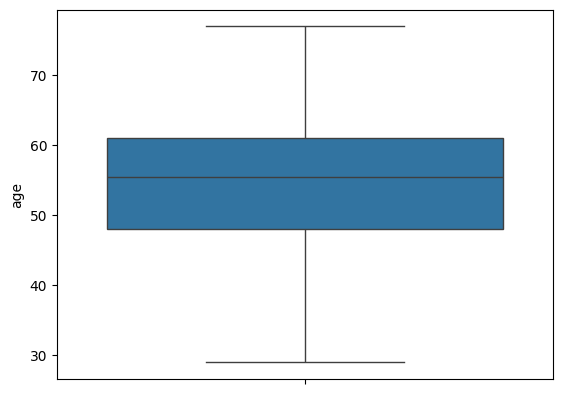

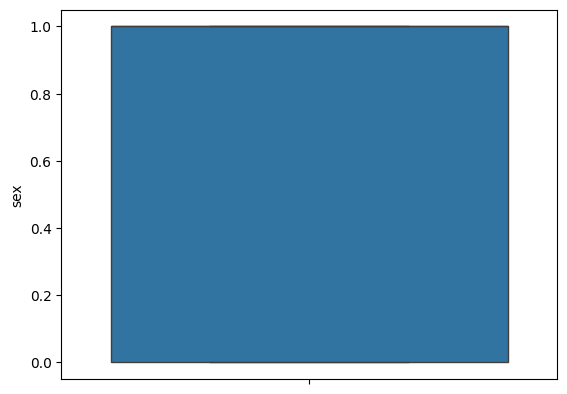

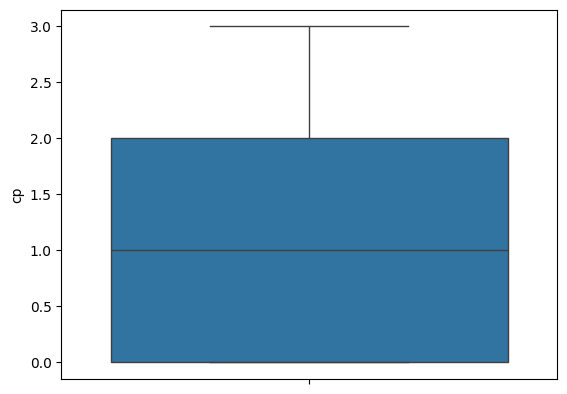

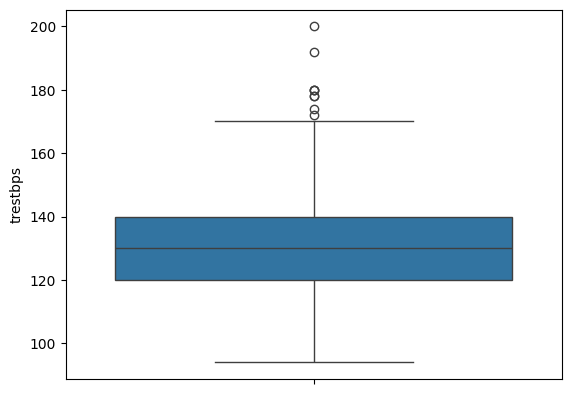

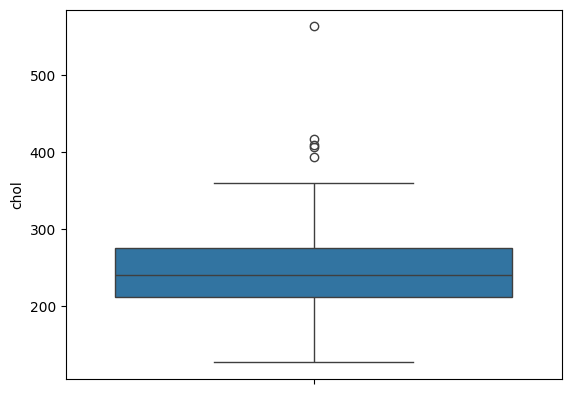

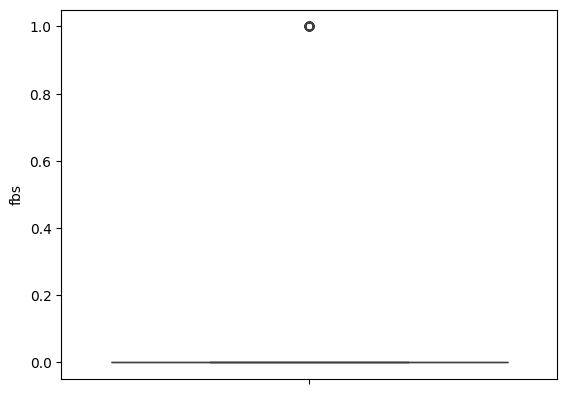

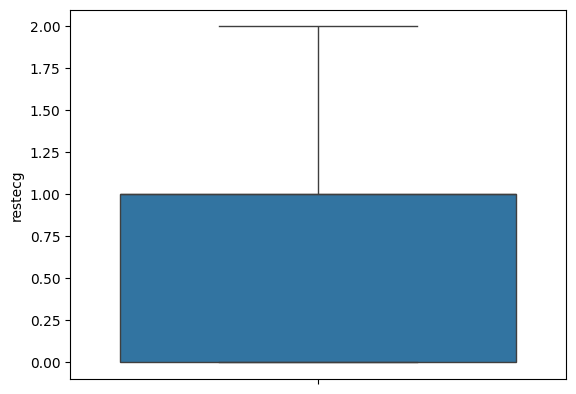

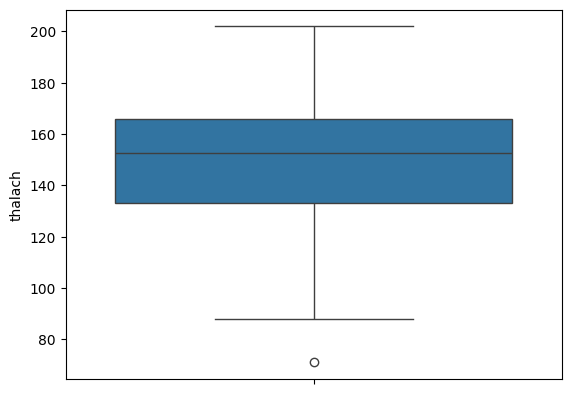

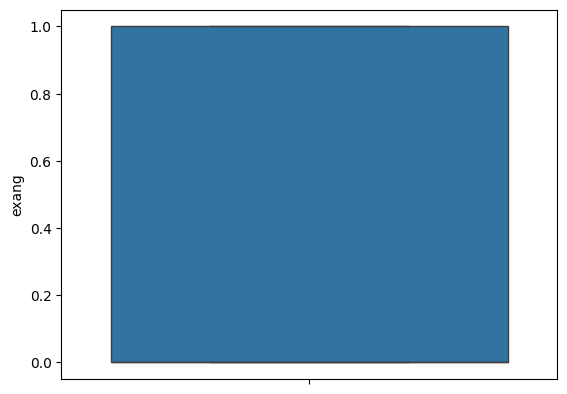

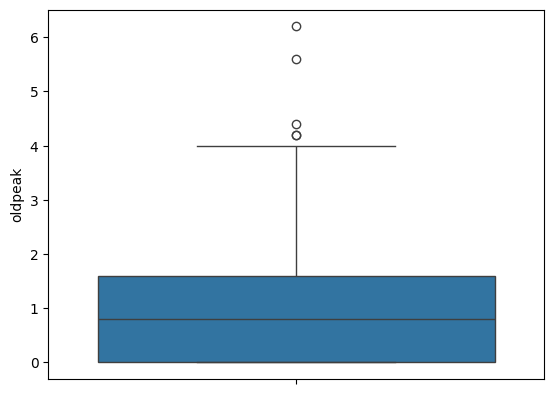

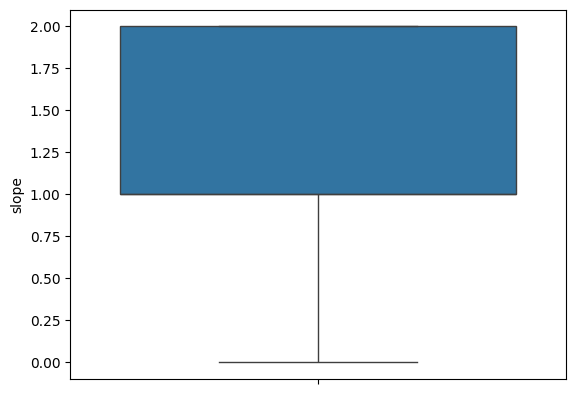

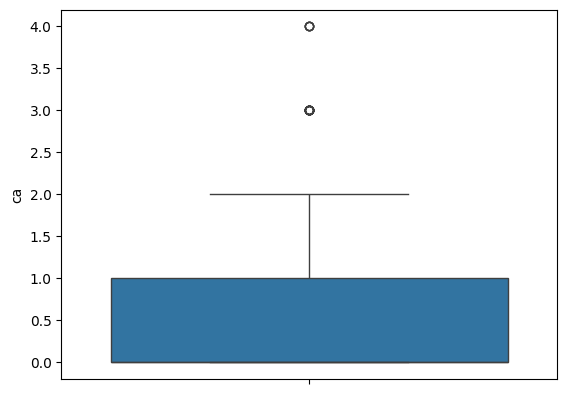

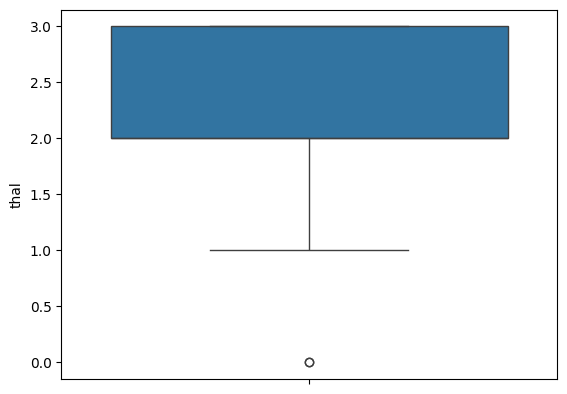

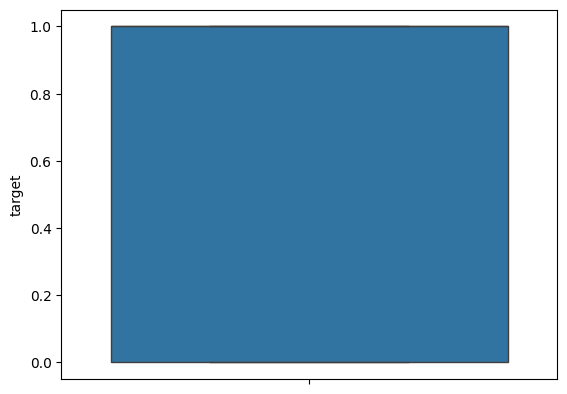

In [17]:
for i in df.columns:
    if(df[i].dtype !='object'):
        sns.boxplot(df[i])
        plt.show()

In [6]:
x=df.iloc[:,:-1]
y=df["target"]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [23]:
y_train

132    1
203    0
197    0
75     1
177    0
      ..
189    0
71     1
106    1
271    0
102    1
Name: target, Length: 241, dtype: int64

In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
dt=DecisionTreeClassifier()

In [11]:
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [12]:
y_pred=dt.predict(x_test)
y_pred

array([0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

In [13]:
new_df=pd.DataFrame()

In [14]:
new_df['Actual']=y_test
new_df['Predicted']=y_pred

In [15]:
new_df

,Actual,Predicted
180,0,0
229,0,0
111,1,1
247,0,1
60,1,1
...,...,...
250,0,0
104,1,1
300,0,0
194,0,0


In [16]:
from sklearn.metrics import *

In [17]:
sc=accuracy_score(y_pred,y_test)
sc*100

77.04918032786885

In [18]:
confusion_matrix(y_test,y_pred)

array([[25,  4],
       [10, 22]])

[Text(0.5663265306122449, 0.9583333333333334, 'x[12] <= 2.5\ngini = 0.495\nsamples = 241\nvalue = [109, 132]'),
 Text(0.32142857142857145, 0.875, 'x[11] <= 0.5\ngini = 0.382\nsamples = 148\nvalue = [38, 110]'),
 Text(0.44387755102040816, 0.9166666666666667, 'True  '),
 Text(0.20408163265306123, 0.7916666666666666, 'x[9] <= 1.7\ngini = 0.208\nsamples = 102\nvalue = [12, 90]'),
 Text(0.12244897959183673, 0.7083333333333334, 'x[0] <= 58.5\ngini = 0.139\nsamples = 93\nvalue = [7, 86]'),
 Text(0.061224489795918366, 0.625, 'x[3] <= 109.0\ngini = 0.028\nsamples = 71\nvalue = [1, 70]'),
 Text(0.04081632653061224, 0.5416666666666666, 'x[1] <= 0.5\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.02040816326530612, 0.4583333333333333, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.061224489795918366, 0.4583333333333333, 'x[4] <= 232.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.04081632653061224, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.08163265306122448, 0.375

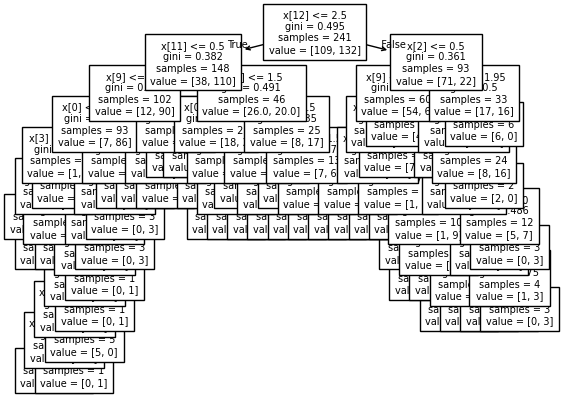

In [19]:
from sklearn import tree
tree.plot_tree(dt,fontsize=7)

In [20]:
dt.get_depth()

11

In [21]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  dt=DecisionTreeClassifier(max_depth=i,random_state=42)
  dt.fit(x_train,y_train)
  y_pred=dt.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(f'Max_depth is {i} Accuracy Score is {acc}')

Max_depth is 1 Accuracy Score is 0.7213114754098361
Max_depth is 2 Accuracy Score is 0.7377049180327869
Max_depth is 3 Accuracy Score is 0.7868852459016393
Max_depth is 4 Accuracy Score is 0.8032786885245902
Max_depth is 5 Accuracy Score is 0.8032786885245902
Max_depth is 6 Accuracy Score is 0.7704918032786885
Max_depth is 7 Accuracy Score is 0.7704918032786885
Max_depth is 8 Accuracy Score is 0.7868852459016393
Max_depth is 9 Accuracy Score is 0.7704918032786885
Max_depth is 10 Accuracy Score is 0.7868852459016393
Max_depth is 11 Accuracy Score is 0.7704918032786885
Max_depth is 12 Accuracy Score is 0.7704918032786885
Max_depth is 13 Accuracy Score is 0.7704918032786885


In [23]:
dt1=DecisionTreeClassifier(max_depth=4,random_state=42)

In [24]:
dt1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [25]:
y_pred1=dt1.predict(x_test)
y_pred1

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [26]:
accuracy_score(y_test,y_pred1)

0.8032786885245902